# EES 322 Lab 2: Spectral Indices from Landsat 8

## NDVI, NDWI, SAVI and NBR

### Aim
To implement, evaluate, and interpret satellite image-processing algorithms using Landsat 8 surface-reflectance data.

### Learning outcomes
By the end of this exercise, you should be able to:

1. Acquire a cloud-screened Landsat 8 Collection 2 Level-2 scene in Google Earth Engine.
2. Select the correct Landsat bands for NDVI, NDWI, SAVI and NBR.
3. Implement each index from its mathematical equation.
4. Visualise and compare the spatial patterns of the four indices.
5. Evaluate index ranges, distributions and relationships.
6. Interpret index values in terms of vegetation, water, exposed soil/built-up surfaces, and disturbance.
7. Explain why SAVI may behave differently from NDVI where vegetation cover is sparse.
8. Explain why a single-date NBR image should not by itself be interpreted as a burn-severity map.

---

### Prerequisite practical
This exercise continues the Landsat acquisition and visualisation workflow from:

[**Landsat image acquisition practical — open in Google Colab**](https://colab.research.google.com/github/rebekah-iisertvm/remote_sensing_lab_iisertvm/blob/main/Landsat_Colab_GitHub_Lab.ipynb)

The essential acquisition, scaling and cloud-masking steps are repeated below because separate Colab notebooks do not share the same runtime.


## Part A — Set up Google Earth Engine

Run the cells in order.

> Replace `PROJECT_ID` only if your class has been assigned a different Earth Engine-enabled Google Cloud project.


In [1]:
%pip -q install -U geemap

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Packages imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.3 MB/s eta 0:00:00
Packages imported successfully.


In [2]:
PROJECT_ID = "ees322-lab"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine initialised.")

Earth Engine initialised.


## Part B — Define the area of interest

The default example is centred near Thiruvananthapuram, Kerala. The same general workflow can be repeated for another location by changing the coordinates.

Earth Engine coordinates are entered as **[longitude, latitude]**.


In [3]:
CENTER_LON = 76.9366
CENTER_LAT = 8.5241

centre = ee.Geometry.Point([CENTER_LON, CENTER_LAT])
aoi = centre.buffer(20_000).bounds()

print("AOI created.")

AOI created.


## Part C — Acquire Landsat 8 surface-reflectance data

We use:

`LANDSAT/LC08/C02/T1_L2`

This is Landsat 8 Collection 2, Level 2, Tier 1. The optical bands are stored as scaled integers. For `SR_B1`–`SR_B7`, surface reflectance is obtained using:

\[
\rho = DN \times 0.0000275 - 0.2
\]

The code also masks cloud, cirrus, cloud shadow, snow, and radiometrically saturated pixels.


In [4]:
START_DATE = "2025-01-01"
END_DATE   = "2025-12-31"
MAX_CLOUD  = 60

raw_collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD))
)

scene_count = raw_collection.size().getInfo()
print("Number of matching scenes:", scene_count)

if scene_count == 0:
    raise ValueError("No scenes found. Increase the date range or MAX_CLOUD.")

Number of matching scenes: 32


In [5]:
def preprocess_landsat8(image):
    qa = image.select("QA_PIXEL")

    # QA_PIXEL:
    # bit 1 = dilated cloud
    # bit 2 = cirrus
    # bit 3 = cloud
    # bit 4 = cloud shadow
    # bit 5 = snow
    clear_mask = (
        qa.bitwiseAnd(1 << 1).eq(0)
        .And(qa.bitwiseAnd(1 << 2).eq(0))
        .And(qa.bitwiseAnd(1 << 3).eq(0))
        .And(qa.bitwiseAnd(1 << 4).eq(0))
        .And(qa.bitwiseAnd(1 << 5).eq(0))
    )

    saturation_mask = image.select("QA_RADSAT").eq(0)

    optical = (
        image.select("SR_B[1-7]")
        .multiply(0.0000275)
        .add(-0.2)
    )

    return (
        image.addBands(optical, None, True)
        .updateMask(clear_mask)
        .updateMask(saturation_mask)
    )

raw_image = ee.Image(raw_collection.sort("CLOUD_COVER").first())
image = preprocess_landsat8(raw_image)

print("Product ID:", raw_image.get("LANDSAT_PRODUCT_ID").getInfo())
print("Acquisition date:", raw_image.date().format("YYYY-MM-dd").getInfo())
print("Scene cloud cover (%):", raw_image.get("CLOUD_COVER").getInfo())

Product ID: LC08_L2SP_144054_20250225_20250304_02_T1
Acquisition date: 2025-02-25
Scene cloud cover (%): 0.48


### Checkpoint 1

Before calculating any index, answer:

1. Why should the Landsat Collection 2 scale factor **and offset** be applied before calculating these indices?
2. Why is pixel-level cloud masking still necessary even after filtering scenes by `CLOUD_COVER`?
3. Which band represents Red, Green, NIR, SWIR1 and SWIR2 in Landsat 8 OLI?

Use the table below.

| Spectral region | Landsat 8 band |
|---|---|
| Green | `SR_B3` |
| Red | `SR_B4` |
| NIR | `SR_B5` |
| SWIR1 | `SR_B6` |
| SWIR2 | `SR_B7` |


## Part D — Understand the four indices

### 1. Normalized Difference Vegetation Index (NDVI)


NDVI = (NIR - Red)/(NIR + Red)


Healthy green vegetation generally has stronger NIR reflectance and lower red reflectance, producing positive NDVI.

---

### 2. Normalized Difference Water Index (NDWI)

In this practical, **NDWI means the McFeeters water index**:


NDWI = (Green - NIR)/(Green + NIR)


It is designed to enhance open-water features.

> **Important terminology:** Another index is sometimes also called NDWI in the literature: \((NIR-SWIR)/(NIR+SWIR)\). In many Landsat workflows that index is called **NDMI**. Do not mix the two definitions.

---

### 3. Soil-Adjusted Vegetation Index (SAVI)


SAVI = [(NIR-Red)(NIR+Red+L)] (1+L)


where \(L\) is a soil-brightness correction factor. We will use:

\[
L=0.5
\]

SAVI is useful where vegetation is sparse enough that the soil background influences the vegetation signal.

---

### 4. Normalized Burn Ratio (NBR)

NBR = (NIR-SWIR2)/(NIR+SWIR2)

Vegetation commonly has relatively high NIR and lower SWIR2 reflectance. Disturbed, dry, or burned surfaces can reduce this contrast.

> A single NBR image is **not automatically a burn-severity map**. Burn severity is commonly evaluated from the change between pre-fire and post-fire NBR, i.e. \(dNBR=NBR_{pre}-NBR_{post}\).


## Part E — Implement NDVI, NDWI, SAVI and NBR

We use `ee.Image.expression()` rather than `normalizedDifference()` so that atmospherically corrected pixels with small negative reflectance values are not automatically discarded.

### Exercise
Read each equation above and confirm that the correct Landsat 8 bands are used in the implementation below.


In [6]:
# Select the reflectance bands once for clarity.
green = image.select("SR_B3")
red   = image.select("SR_B4")
nir   = image.select("SR_B5")
swir2 = image.select("SR_B7")

# NDVI
ndvi = image.expression(
    "(NIR - RED) / (NIR + RED)",
    {"NIR": nir, "RED": red}
).rename("NDVI")

# McFeeters NDWI
ndwi = image.expression(
    "(GREEN - NIR) / (GREEN + NIR)",
    {"GREEN": green, "NIR": nir}
).rename("NDWI")

# SAVI
L = 0.5
savi = image.expression(
    "((NIR - RED) / (NIR + RED + L)) * (1 + L)",
    {"NIR": nir, "RED": red, "L": L}
).rename("SAVI")

# NBR
nbr = image.expression(
    "(NIR - SWIR2) / (NIR + SWIR2)",
    {"NIR": nir, "SWIR2": swir2}
).rename("NBR")

index_image = image.addBands([ndvi, ndwi, savi, nbr])

print("Index bands added:")
print(index_image.bandNames().getInfo())

Index bands added:
['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI', 'NDWI', 'SAVI', 'NBR']


### Checkpoint 2 — Explain the algorithms

For each index, write **one or two sentences** explaining:

1. Which two spectral regions create the contrast?
2. What surface property is the index trying to enhance?
3. What could produce an ambiguous value?

For example, do not assume that every positive NDWI pixel is definitely water or that every low-NBR pixel is definitely burned.


## Part F — Visualise the original image and the four index maps

Turn layers on and off using the layer-control button on the interactive map.

Suggested interpretation ranges are used only for display. They are **not universal classification thresholds**.


In [7]:
Map = geemap.Map()
Map.centerObject(aoi, 10)

true_color = {
    "bands": ["SR_B4", "SR_B3", "SR_B2"],
    "min": 0.0,
    "max": 0.30,
}

false_color = {
    "bands": ["SR_B5", "SR_B4", "SR_B3"],
    "min": 0.0,
    "max": 0.35,
}

Map.addLayer(image.clip(aoi), true_color, "True colour (4-3-2)", True)
Map.addLayer(image.clip(aoi), false_color, "False colour (5-4-3)", False)

Map.addLayer(
    ndvi.clip(aoi),
    {"min": -1, "max": 1, "palette": ["8c510a", "f6e8c3", "01665e"]},
    "NDVI",
    False,
)

Map.addLayer(
    ndwi.clip(aoi),
    {"min": -1, "max": 1, "palette": ["a6611a", "f5f5f5", "018571"]},
    "NDWI (McFeeters)",
    False,
)

Map.addLayer(
    savi.clip(aoi),
    {"min": -1, "max": 1, "palette": ["8c510a", "f6e8c3", "01665e"]},
    "SAVI",
    False,
)

Map.addLayer(
    nbr.clip(aoi),
    {"min": -1, "max": 1, "palette": ["b2182b", "f7f7f7", "2166ac"]},
    "NBR",
    False,
)

Map.addLayer(aoi, {"color": "black"}, "AOI", False)
Map

Map(center=[8.524120270793116, 76.93689615892917], controls=(WidgetControl(options=['position', 'transparent_b…

### Exercise 1 — Visual interpretation

Compare each index with the true-colour and false-colour images.

Record observations for at least **three surface types** visible in the scene, such as:

- dense vegetation,
- sparse vegetation or exposed soil,
- built-up land,
- inland/coastal water.

For each surface type, describe whether NDVI, NDWI, SAVI and NBR are relatively high, intermediate or low.

Then answer:

1. Which index most clearly separates vegetation from non-vegetated land?
2. Which index most clearly enhances open water?
3. Where do NDVI and SAVI differ most noticeably?
4. Does low NBR uniquely identify burned land in this scene? Why or why not?


## Part G — Quantitative evaluation

Visual interpretation is useful, but an algorithm should also be checked quantitatively.

Here we will:

1. calculate summary statistics,
2. sample clear pixels,
3. inspect index distributions,
4. compare NDVI and SAVI directly.

> In this practical, **evaluation** means checking numerical behaviour, spatial consistency and spectral interpretation. It is not a formal accuracy assessment because no independent ground-truth reference dataset is supplied.


In [8]:
indices = index_image.select(["NDVI", "NDWI", "SAVI", "NBR"])

stats = indices.reduceRegion(
    reducer=(
        ee.Reducer.mean()
        .combine(ee.Reducer.stdDev(), sharedInputs=True)
        .combine(ee.Reducer.minMax(), sharedInputs=True)
    ),
    geometry=aoi,
    scale=30,
    maxPixels=1e8,
    bestEffort=True,
)

stats_dict = stats.getInfo()

summary_rows = []
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    summary_rows.append({
        "Index": name,
        "Mean": stats_dict.get(f"{name}_mean"),
        "StdDev": stats_dict.get(f"{name}_stdDev"),
        "Min": stats_dict.get(f"{name}_min"),
        "Max": stats_dict.get(f"{name}_max"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Index,Mean,StdDev,Min,Max
0,NDVI,0.465020,4.315832,-653.400000,286.000000
1,NDWI,-0.134025,5.496382,-847.000000,711.333333
2,SAVI,0.261721,0.205016,-0.237005,0.735935
3,NBR,0.023209,8.545481,-748.000000,1031.800000


### Checkpoint 3 — Range check

The normalized-difference equations are often described as having a theoretical range of approximately **−1 to +1** when the input reflectances are non-negative.

Inspect the minimum and maximum values above.

- Do any values slightly exceed that range?
- If so, consider atmospheric correction, residual noise, very small denominators, and the fact that Collection 2 surface-reflectance products can contain small negative corrected reflectances.
- Should such pixels automatically be interpreted as physically meaningful extremes?


In [9]:
sample_fc = indices.sample(
    region=aoi,
    scale=30,
    numPixels=2500,
    seed=42,
    geometries=False,
    tileScale=2,
)

sample_info = sample_fc.getInfo()

sample_df = pd.DataFrame(
    [feature["properties"] for feature in sample_info["features"]]
).dropna()

print("Number of sampled clear pixels:", len(sample_df))
sample_df.head()

Number of sampled clear pixels: 2500


,NBR,NDVI,NDWI,SAVI
0,-1.043710,-3.928571,1.030114,-0.000825
1,0.596288,0.786297,-0.741107,0.460252
2,-1.590541,-0.012429,1.382830,0.000083
3,-0.198357,0.047576,0.289357,0.002315
4,0.253971,0.423153,-0.452152,0.253858


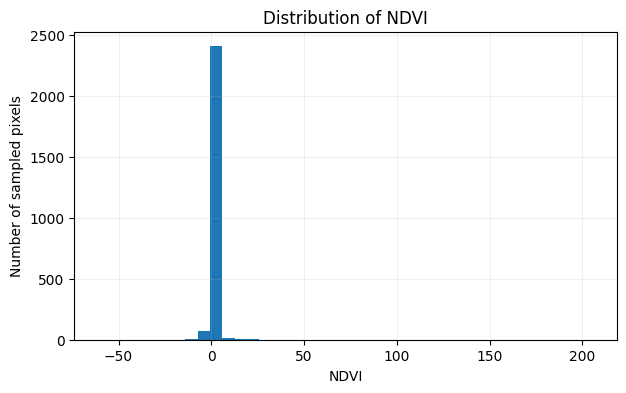

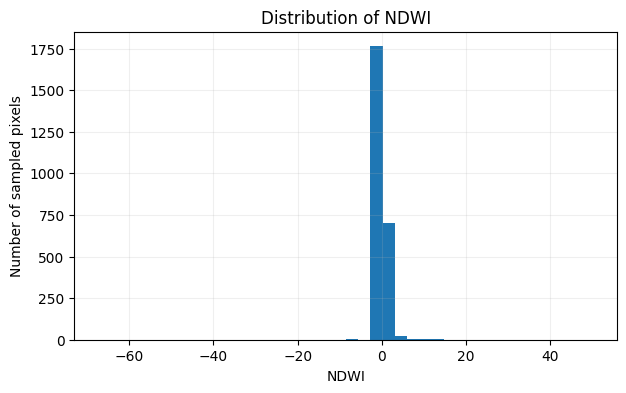

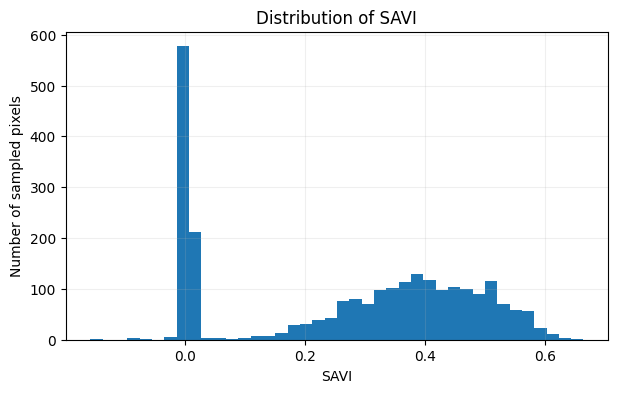

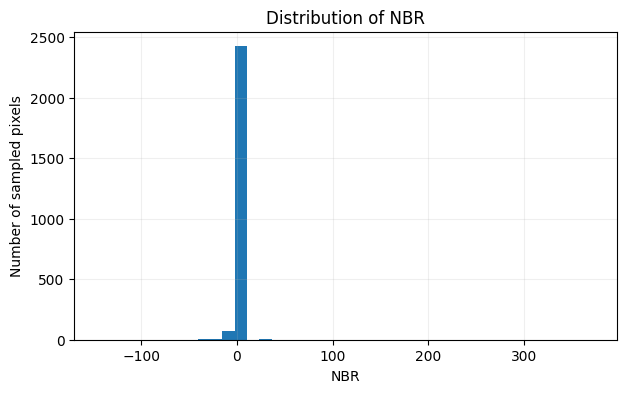

In [10]:
# Plot a separate histogram for each index.
for name in ["NDVI", "NDWI", "SAVI", "NBR"]:
    plt.figure(figsize=(7, 4))
    plt.hist(sample_df[name], bins=40)
    plt.xlabel(name)
    plt.ylabel("Number of sampled pixels")
    plt.title(f"Distribution of {name}")
    plt.grid(alpha=0.2)
    plt.show()

### Exercise 2 — Evaluate the distributions

For each histogram:

1. Is the distribution unimodal, bimodal, or more complex?
2. Which index contains the widest spread of values?
3. Which index appears best suited to separating water from most land pixels?
4. Which index is most strongly influenced by vegetation abundance?
5. Explain why the distributions depend on the particular scene and AOI.


In [11]:
# Compare NDVI and SAVI numerically.
sample_df["NDVI_minus_SAVI"] = sample_df["NDVI"] - sample_df["SAVI"]

comparison = sample_df[["NDVI", "SAVI", "NDVI_minus_SAVI"]].describe()
comparison

,NDVI,SAVI,NDVI_minus_SAVI
count,2500.000000,2500.000000,2500.000000
mean,0.578080,0.268635,0.309444
std,4.609279,0.204281,4.605764
min,-60.500000,-0.157749,-60.507261
25%,0.306341,0.007489,0.177718
50%,0.624880,0.323666,0.277844
75%,0.783213,0.438865,0.321052
max,205.333333,0.663836,205.324094


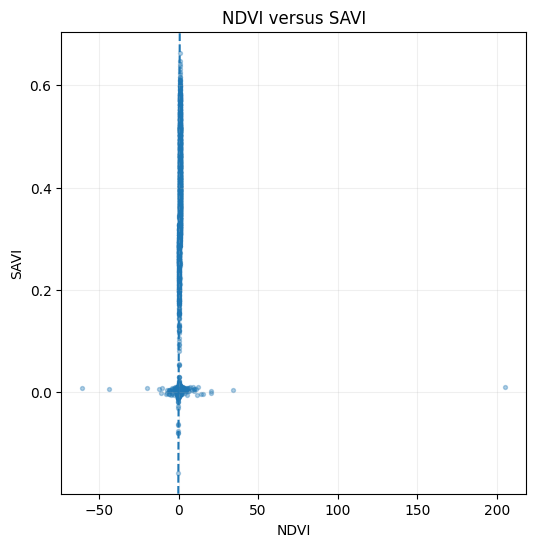

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(sample_df["NDVI"], sample_df["SAVI"], s=8, alpha=0.35)
plt.xlabel("NDVI")
plt.ylabel("SAVI")
plt.title("NDVI versus SAVI")
plt.axline((0, 0), slope=1, linestyle="--")
plt.grid(alpha=0.2)
plt.show()

### Exercise 3 — NDVI versus SAVI

Use the scatter plot and image maps to answer:

1. Are NDVI and SAVI strongly related?
2. Why are they not identical?
3. Where would you expect the soil-adjustment term to matter most?
4. What would happen to SAVI if \(L=0\)?
5. Change `L` to `0.25` and `1.0`, rerun the relevant cells, and describe how the result changes.


## Part H — Build simple interpretation masks

The following thresholds are used only as **exploratory examples**. Spectral-index thresholds are scene-, season-, atmosphere-, sensor-, and land-cover-dependent.

Do not treat these masks as validated land-cover classifications.


In [13]:
vegetation_candidate = ndvi.gt(0.40).rename("Vegetation_candidate")
water_candidate = ndwi.gt(0.00).rename("Water_candidate")

MaskMap = geemap.Map()
MaskMap.centerObject(aoi, 10)
MaskMap.addLayer(image.clip(aoi), true_color, "True colour", True)
MaskMap.addLayer(
    vegetation_candidate.selfMask().clip(aoi),
    {"palette": ["00AA00"]},
    "NDVI > 0.40",
    False,
)
MaskMap.addLayer(
    water_candidate.selfMask().clip(aoi),
    {"palette": ["0000FF"]},
    "NDWI > 0",
    False,
)
MaskMap

Map(center=[8.524120270793116, 76.93689615892917], controls=(WidgetControl(options=['position', 'transparent_b…

### Exercise 4 — Threshold evaluation

Inspect the masks against the original Landsat image.

1. Identify at least two places where the vegetation mask appears reasonable.
2. Identify at least one possible omission or commission error.
3. Does `NDWI > 0` capture all visible water?
4. Does it mistakenly include any bright or shadowed non-water surfaces?
5. Explain why threshold tuning from one scene should not automatically be transferred to another scene.


## Part I — NBR interpretation and the difference between NBR and dNBR

NBR is useful because vegetation commonly produces a strong NIR–SWIR2 contrast. However, a low NBR value can also occur over non-vegetated, dry, urban, rocky, or water surfaces.

For a wildfire application, a stronger design is:

\[
dNBR = NBR_{pre-fire} - NBR_{post-fire}
\]

A positive dNBR indicates a decrease in NBR after the event, but burn-severity interpretation still requires appropriate temporal selection, cloud screening, local calibration, and ideally independent reference information.

### Optional extension
Choose a documented fire event and:

1. acquire a suitable pre-fire Landsat scene,
2. acquire a suitable post-fire Landsat scene,
3. calculate NBR for both dates,
4. calculate dNBR,
5. compare the change map with the original spectral imagery.

Do **not** label the result as a validated burn-severity product unless you have an appropriate validation dataset and severity-class definition.


## Part J — Export your index stack

This cell prepares an export of NDVI, NDWI, SAVI and NBR to Google Drive as a GeoTIFF.

Uncomment `task.start()` when you are ready to submit the export.


In [14]:
export_indices = index_image.select(["NDVI", "NDWI", "SAVI", "NBR"]).clip(aoi)

task = ee.batch.Export.image.toDrive(
    image=export_indices,
    description="Landsat8_Spectral_Indices",
    folder="EarthEngine",
    fileNamePrefix="Landsat8_NDVI_NDWI_SAVI_NBR",
    region=aoi,
    scale=30,
    maxPixels=1e9,
    fileFormat="GeoTIFF",
)

# task.start()

print("Export prepared. Uncomment task.start() to submit it.")

Export prepared. Uncomment task.start() to submit it.


# Final submission exercise

Prepare a short practical report containing:

### 1. Data
- Landsat product ID
- acquisition date
- AOI
- cloud-cover value
- preprocessing steps applied

### 2. Algorithm table
For NDVI, NDWI, SAVI and NBR, provide:
- equation,
- Landsat bands used,
- principal target or interpretation,
- one important limitation.

### 3. Results
Include:
- true-colour image,
- NDVI map,
- NDWI map,
- SAVI map,
- NBR map,
- summary-statistics table,
- at least two distribution plots,
- NDVI-versus-SAVI comparison.

### 4. Interpretation
Answer in your own words:

1. Why is NDVI sensitive to green vegetation?
2. Why does the McFeeters NDWI often enhance water?
3. Why can SAVI be preferable to NDVI in sparsely vegetated areas?
4. Why should NBR not be interpreted as a burn-severity product from one image alone?
5. Which index was most informative for this particular AOI, and why?

### 5. Critical evaluation
Describe at least **three sources of uncertainty or ambiguity**, such as:
- residual cloud or cloud shadow,
- atmospheric-correction artefacts,
- mixed pixels,
- seasonal effects,
- threshold sensitivity,
- similar spectral responses from different land-cover types,
- spatial resolution.


## References and technical notes

- Original course notebook:  
  https://github.com/rebekah-iisertvm/remote_sensing_lab_iisertvm/blob/main/Landsat_Colab_GitHub_Lab.ipynb
- Google Earth Engine Landsat 8 Collection 2 Level-2 catalog:  
  https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2
- Google Earth Engine `ee.Image.normalizedDifference()` documentation:  
  https://developers.google.com/earth-engine/apidocs/ee-image-normalizeddifference
- McFeeters, S. K. (1996). The use of the Normalized Difference Water Index (NDWI) in the delineation of open water features.
- Huete, A. R. (1988). A Soil-Adjusted Vegetation Index (SAVI).
- Key, C. H. & Benson, N. C. Burn-severity mapping approaches using NBR/dNBR.

**Technical note:** This notebook calculates the normalized-difference indices with `ee.Image.expression()` because Earth Engine's `normalizedDifference()` masks a pixel if either input band is negative. That behaviour can remove some valid atmospherically corrected Landsat surface-reflectance pixels.
